In [74]:
import pandas as pd
import numpy as np

data = [['John', 50, 'Austin', 100],
        ['Cataline', 45 , 'San Francisco', 80],
        ['Matt', 30, 'Boston' , 95],
        ['Matt', 35, 'Sydney' , 98]
       ]

columns = ['Name', 'Age', 'City', 'Marks']

#row indexes
idx = ['w','x', 'y', 'z']

df=pd.DataFrame(data, columns=columns, index=idx)


print(df) #dataframe can be craeted with or without indices
print ("hello world")

       Name  Age           City  Marks
w      John   50         Austin    100
x  Cataline   45  San Francisco     80
y      Matt   30         Boston     95
z      Matt   35         Sydney     98
hello world


In [75]:
newidx=[1,2,3,4] #setting anew index, which is not actually a column
df.index=newidx
print (df.index)
print (f"The lowest mark and the index for that is "+str(df['Marks'].min()) +str(" ")+str(df['Marks'].idxmin()))
df.reset_index(drop=True, inplace=True)
df['Marks'].idxmin(), df

Index([1, 2, 3, 4], dtype='int64')
The lowest mark and the index for that is 80 2


(1,
        Name  Age           City  Marks
 0      John   50         Austin    100
 1  Cataline   45  San Francisco     80
 2      Matt   30         Boston     95
 3      Matt   35         Sydney     98)

In [76]:
l= [1,3,1,5,7,3]
df.Name.unique(), df.Name.value_counts().values, np.unique([1,3,1,5,7,3], return_counts=True, return_inverse=True, return_index=True),np.take(l,[0,1,3,4])
print()
print(np.unique([1,3,1,5,7,3], return_counts=True))
print(np.unique([1,3,1,5,7,3], return_index=True))
print(np.unique([1,3,1,5,7,3], return_inverse=True))
print(pd.Series(np.unique([1,3,1,5,7,3])).value_counts())



(array([1, 3, 5, 7]), array([2, 2, 1, 1]))
(array([1, 3, 5, 7]), array([0, 1, 3, 4]))
(array([1, 3, 5, 7]), array([0, 1, 0, 2, 3, 1]))
1    1
3    1
5    1
7    1
Name: count, dtype: int64


In [77]:
l= [1,3,1,5,7,3]
df.Name.unique(), df.Name.value_counts().values

(array(['John', 'Cataline', 'Matt'], dtype=object), array([2, 1, 1]))

In [78]:
# Create a Dict from a input ??? a series can contain data of different datatypes
data = {'Courses' :"pandas", 'Fees' : 20000, 'Duration' : "30days"}
s2 = pd.Series(data)
print (s2, type(s2)) #This is like 2D, but still a series

Courses     pandas
Fees         20000
Duration    30days
dtype: object <class 'pandas.core.series.Series'>


In [79]:
data = ['python','php','java', 'MalayalaM','Ava','abi']
s2 = pd.Series(data) #, index=['r1', 'r2','r3'])
print(s2) #series ca also be created with/without index
#s3=s2.apply(lambda x: x if x[::-1]==x else "Not")
s3=s2.apply(lambda x: x if x==x[::-1] else "Not a palindrome") 
[x +" - palindrome" if x.lower()==x[::-1].lower() else "Not a palindrome" for x in s2] , s3


0       python
1          php
2         java
3    MalayalaM
4          Ava
5          abi
dtype: object


(['Not a palindrome',
  'php - palindrome',
  'Not a palindrome',
  'MalayalaM - palindrome',
  'Ava - palindrome',
  'Not a palindrome'],
 0    Not a palindrome
 1                 php
 2    Not a palindrome
 3           MalayalaM
 4    Not a palindrome
 5    Not a palindrome
 dtype: object)

In [80]:
df[(df['Name'].str.contains('Jo')) | (df['Name'].str.contains('Ma'))] #filtering from dataframe



,Name,Age,City,Marks
0,John,50,Austin,100
2,Matt,30,Boston,95
3,Matt,35,Sydney,98


In [81]:
#df[~df['Name'].isin(['John'])]
df[~df['Name'].str.contains('John') & ~df['Name'].str.contains('Matt')]

,Name,Age,City,Marks
1,Cataline,45,San Francisco,80


In [82]:
df

,Name,Age,City,Marks
0,John,50,Austin,100
1,Cataline,45,San Francisco,80
2,Matt,30,Boston,95
3,Matt,35,Sydney,98


In [83]:
df.groupby("City")['Age'].mean()

City
Austin           50.0
Boston           30.0
San Francisco    45.0
Sydney           35.0
Name: Age, dtype: float64

In [84]:
df.groupby("Name", as_index=False)['Age','Marks'].mean()

ValueError: Cannot subset columns with a tuple with more than one element. Use a list instead.

In [ ]:
df.groupby("Name")['Age'].mean().reset_index() #inplace=True, drop=False)

,Name,Age
0,Cataline,45.0
1,John,50.0
2,Matt,32.5


In [ ]:
df


,Name,Age,City,Marks
x,John,50,Austin,70
y,Cataline,45,San Francisco,80
z,Matt,30,Boston,95


In [ ]:
df.groupby("Name").agg({'Age':'mean','Marks':'max'}).reset_index()

,Name,Age,Marks
0,Cataline,45.0,80
1,John,50.0,100
2,Matt,32.5,98


In [ ]:
data = {
    'Name': ['John', 'Matt', 'John', 'Cateline'],
    'math_Marks': [18, 20, 19, 15],
    'science_Marks': [10, 20, 15, 12]
}
df=pd.DataFrame(data, index=np.arange(4))
df['TotalMarks']=df.apply(lambda row: row['math_Marks']+row['science_Marks'], axis=1)
df['Total_Marks']=df.apply(lambda x:x['math_Marks']+x['science_Marks'], axis=1)

df['TMarks']= df['math_Marks']+df['science_Marks']
df["TMarks2"]= df[['math_Marks','science_Marks']].sum(axis=1)
df["Tmarks3"]= df.apply(lambda x: x['math_Marks']+x['science_Marks'], axis=1)
df["TMarks4"]= df.apply(lambda x: x[['math_Marks','science_Marks']].sum(), axis=1)
df

,Name,math_Marks,science_Marks,TotalMarks,Total_Marks,TMarks,TMarks2,Tmarks3,TMarks4
0,John,18,10,28,28,28,28,28,28
1,Matt,20,20,40,40,40,40,40,40
2,John,19,15,34,34,34,34,34,34
3,Cateline,15,12,27,27,27,27,27,27


In [ ]:
df['TMarks']=df['math_Marks']+ df['science_Marks']
df['TMarks']

0    28
1    40
2    34
3    27
Name: TMarks, dtype: int64

In [ ]:
df['math_Marks'].fillna(df['math_Marks'].median(), inplace=True)
s=pd.Series(df['math_Marks'])
s, type(s)

(0    18
 1    20
 2    19
 3    15
 Name: math_Marks, dtype: int64,
 pandas.core.series.Series)

In [ ]:
data = {
    'Name': ['John', 'Matt', 'John', 'Cateline'],
    'math_Marks': [18, 20, 19, 15],
    'science_Marks': [10, 20, 15, 12]
}

df = pd.DataFrame(data)

#one hot encoding
df_onehot=pd.get_dummies(df,columns=['Name'],drop_first=True) #drop_first is always suggested to avoid dummy trap error

print(df_onehot)
ID=[1, 22, 23, 36]

df_onehot.insert(3,"TMarks", value=df['math_Marks']+df['science_Marks'])
df_onehot['math_Marks']=df['math_Marks'].astype('float64') #df['math_Marks'].astype('float64')
df_onehot['ID'] = ID
df_onehot['ID']=df_onehot['ID'].astype(str)

df_onehot['Name_John']=df_onehot['Name_John'].astype('category')
print(df_onehot.dtypes)

df_onehot, df_onehot.select_dtypes(exclude= ['object','category'] )

   math_Marks  science_Marks  Name_John  Name_Matt
0          18             10       True      False
1          20             20      False       True
2          19             15       True      False
3          15             12      False      False
math_Marks        float64
science_Marks       int64
Name_John        category
TMarks              int64
Name_Matt            bool
ID                 object
dtype: object


(   math_Marks  science_Marks Name_John  TMarks  Name_Matt  ID
 0        18.0             10      True      28      False   1
 1        20.0             20     False      40       True  22
 2        19.0             15      True      34      False  23
 3        15.0             12     False      27      False  36,
    math_Marks  science_Marks  TMarks  Name_Matt
 0        18.0             10      28      False
 1        20.0             20      40       True
 2        19.0             15      34      False
 3        15.0             12      27      False)

In [ ]:
np.random.randint(2,50,10)

array([ 3, 42, 30, 19, 37, 25, 14,  2, 10, 28])

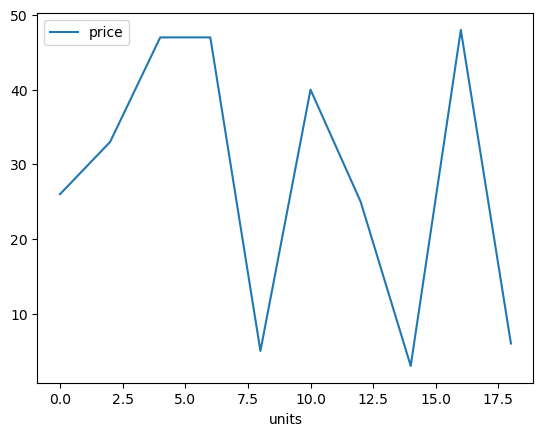

In [ ]:
data = {'units': np.arange(0,20,2),
        'price': np.random.randint(2,50,10)}
# Create a DataFrame df
df = pd.DataFrame(data)


df.plot(x='units', y='price', kind='line');

In [ ]:
s = pd.Series([1, 2, 3, 4])
s.rolling(1).mean(),s.rolling(2).mean(), s.diff(), s.diff().diff()

(0    1.0
 1    2.0
 2    3.0
 3    4.0
 dtype: float64,
 0    NaN
 1    1.5
 2    2.5
 3    3.5
 dtype: float64,
 0    NaN
 1    1.0
 2    1.0
 3    1.0
 dtype: float64,
 0    NaN
 1    NaN
 2    0.0
 3    0.0
 dtype: float64)

In [ ]:
s.rolling(3).mean()

0    NaN
1    NaN
2    2.0
3    3.0
dtype: float64

In [ ]:
pd.Series(s.rolling(2).mean())

0    NaN
1    1.5
2    2.5
3    3.5
dtype: float64

In [86]:
details = { #delete rows based on indices, from a dataframe
    'Name': ['Ankit', 'Aishwarya', 'Shaurya', 'Shivangi', 'Sneha'],
    'Age': [23, 21, 22, 21, 22],
    'University': ['BHU', 'JNU', 'DU', 'BHU', 'JNU']
}

details=pd.DataFrame(details, index=np.arange(5))
details.drop([2,3], inplace=True)
print (details )
details.drop(columns=['Age'], axis=1, inplace=True)
details.drop(df.index[[0,1]], inplace=True)

details

        Name  Age University
0      Ankit   23        BHU
1  Aishwarya   21        JNU
4      Sneha   22        JNU


,Name,University
4,Sneha,JNU


In [31]:
details.iloc[1,:].index

Index(['Name', 'University'], dtype='object')

In [23]:
mylist = list('abcedfghijklmnopqrstuvwxyz')
myarr = np.arange(26)
#mydict = dict(zip(mylist, myarr))
mydict=dict(zip(mylist,myarr))
print(mydict)
mydict_df=pd.DataFrame(mydict, index=myarr)
mydict_df

{'a': 0, 'b': 1, 'c': 2, 'e': 3, 'd': 4, 'f': 5, 'g': 6, 'h': 7, 'i': 8, 'j': 9, 'k': 10, 'l': 11, 'm': 12, 'n': 13, 'o': 14, 'p': 15, 'q': 16, 'r': 17, 's': 18, 't': 19, 'u': 20, 'v': 21, 'w': 22, 'x': 23, 'y': 24, 'z': 25}


,a,b,c,e,d,f,g,h,i,j,...,q,r,s,t,u,v,w,x,y,z
0,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
1,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
2,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
3,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
4,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
5,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
6,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
7,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
8,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
9,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25


In [82]:
pd.Series(myarr)

0      0
1      1
2      2
3      3
4      4
5      5
6      6
7      7
8      8
9      9
10    10
11    11
12    12
13    13
14    14
15    15
16    16
17    17
18    18
19    19
20    20
21    21
22    22
23    23
24    24
25    25
dtype: int64

In [83]:
pd.Series(mydict)

a     0
b     1
c     2
e     3
d     4
f     5
g     6
h     7
i     8
j     9
k    10
l    11
m    12
n    13
o    14
p    15
q    16
r    17
s    18
t    19
u    20
v    21
w    22
x    23
y    24
z    25
dtype: int64

In [24]:
mylist_s=pd.Series(mylist)
mylist_s

0     a
1     b
2     c
3     e
4     d
5     f
6     g
7     h
8     i
9     j
10    k
11    l
12    m
13    n
14    o
15    p
16    q
17    r
18    s
19    t
20    u
21    v
22    w
23    x
24    y
25    z
dtype: object

In [25]:
#mylist_s.to_frame().reset_index()
mylist_s.to_frame().reset_index()

,index,0
0,0,a
1,1,b
2,2,c
3,3,e
4,4,d
5,5,f
6,6,g
7,7,h
8,8,i
9,9,j


In [91]:
#Combine ser1 and ser2 to form a dataframe
ser1 = pd.Series(list('abcedfghijklmnopqrstuvwxyz'))
ser2 = pd.Series(np.arange(26))

pd.DataFrame(ser1, ser2).reset_index()

,index,0
0,0,a
1,1,b
2,2,c
3,3,e
4,4,d
5,5,f
6,6,g
7,7,h
8,8,i
9,9,j


In [92]:
#Give a name to the series ser calling it ‘alphabets’.
ser1 = pd.Series(list('abcedfghijklmnopqrstuvwxyz'))
ser1.name='alphabet'
ser1

0     a
1     b
2     c
3     e
4     d
5     f
6     g
7     h
8     i
9     j
10    k
11    l
12    m
13    n
14    o
15    p
16    q
17    r
18    s
19    t
20    u
21    v
22    w
23    x
24    y
25    z
Name: alphabet, dtype: object

In [26]:
#From ser1 remove items present in ser2
ser1 = pd.Series([1, 2, 3, 4, 5])
ser2 = pd.Series([4, 5, 6, 7, 8])

pd.Series([x for x in list(ser1) if x not in list(ser2)])


0    1
1    2
2    3
dtype: int64

In [27]:
ser1[~ser1.isin(ser2)]

0    1
1    2
2    3
dtype: int64

In [113]:
#Compute the minimum, 25th percentile, median, 75th, and maximum of ser
ser = pd.Series(np.random.normal(10, 5, 25))
ser=np.array(ser)
ser.min(), np.percentile(ser, 0.25), np.percentile(ser, 0.50), np.percentile(ser, 0.75), ser.max()
#or
np.percentile(ser, q=[0, 25, 50, 75, 100]) #minimum is 0 percentile

array([ 2.78448557,  7.3283751 , 11.35436787, 12.82395545, 15.56412383])

In [35]:
a = [4, 3, 5, 7, 6, 8] #fancy indexing and usual extraction
np.take(a, [[0, 1], [2, 3]]), a[0:4], np.take(a,[[1,3],[0,5]])

(array([[4, 3],
        [5, 7]]),
 [4, 3, 5, 7],
 array([[3, 7],
        [4, 8]]))

In [34]:
ind=np.random.randint(8, size=30)
ser = pd.Series(np.take(list('abcdefgh'), ind)) #??? how take works
ser, ind

(0     b
 1     c
 2     d
 3     g
 4     a
 5     e
 6     g
 7     g
 8     a
 9     b
 10    d
 11    b
 12    h
 13    d
 14    g
 15    g
 16    c
 17    a
 18    h
 19    f
 20    d
 21    f
 22    a
 23    b
 24    c
 25    b
 26    d
 27    d
 28    g
 29    a
 dtype: object,
 array([1, 2, 3, 6, 0, 4, 6, 6, 0, 1, 3, 1, 7, 3, 6, 6, 2, 0, 7, 5, 3, 5,
        0, 1, 2, 1, 3, 3, 6, 0]))

In [92]:
ser = pd.Series(np.take(list('abcde'), np.random.randint(5, size=5)))
ser1 = pd.Series(np.take(list('abcde'), np.random.randint(5, size=10)))
ser, ser1

(0    b
 1    b
 2    a
 3    c
 4    a
 dtype: object,
 0    c
 1    e
 2    b
 3    e
 4    c
 5    a
 6    b
 7    b
 8    b
 9    d
 dtype: object)

In [40]:
x=[1,3,2,4,6,2,6,8,6]
x.count(1)

1

In [97]:
import collections
x=[1,3,2,4,6,2,6,8,6]
pd.Series(collections.Counter(x)).sort_values(ascending=False).index[:2]

Index([6, 2], dtype='int64')

In [103]:
#keep the top 2 most frequent items as it is and replace everything else as ‘Other’.
x=[1,3,2,4,6,2,6,8,6]
print([a if x.count(a)>=2 else "other" for a in x])
ind=pd.Series(x).value_counts().index[:2]
ind
[a if a in ind else "Other" for a in x], ind
list(set([a for a in x if a in pd.Series(collections.Counter(x)).sort_values(ascending=False).index[:2] ]))

['other', 'other', 2, 'other', 6, 2, 6, 'other', 6]


[2, 6]

In [134]:
ser = pd.Series(np.random.randint(1, 10, 35))
np.array(ser).reshape(7,5)

array([[3, 3, 2, 4, 3],
       [7, 1, 8, 8, 5],
       [1, 4, 4, 6, 9],
       [1, 5, 5, 1, 5],
       [8, 4, 2, 8, 6],
       [5, 9, 2, 1, 3],
       [3, 8, 4, 3, 2]])

In [106]:
#Find the positions of numbers that are multiples of 3 

ser = pd.Series(np.random.randint(1, 10, 7))
print(ser)
[i for i,x in enumerate(list(ser)) if x%3==0],[x for (i,x) in enumerate (list(ser)) if i%3==0]

0    3
1    7
2    6
3    7
4    4
5    3
6    7
dtype: int64


([0, 2, 5], [3, 7, 7])

In [137]:
# Input
ser1 = pd.Series(range(5))
ser2 = pd.Series(list('abcde'))

print(ser1)
print(ser2)

# Output
# Vertical
print(ser1.append(ser2))

# Horizontal
df = pd.concat([ser1, ser2], axis=1)
print(df)

0    0
1    1
2    2
3    3
4    4
dtype: int64
0    a
1    b
2    c
3    d
4    e
dtype: object
0    0
1    1
2    2
3    3
4    4
0    a
1    b
2    c
3    d
4    e
dtype: object
   0  1
0  0  a
1  1  b
2  2  c
3  3  d
4  4  e


In [37]:
#get the positions of items of series A in another series B
ser1 = pd.Series([10, 9, 6, 5, 3, 1, 12, 8, 13])
ser2 = pd.Series([1, 3, 10, 13])
print(ser1[ser1.isin(ser2)])
ser1=list(ser1)
ser2=list(ser2)
[i for i, x in enumerate(ser1) if x in ser2]

0    10
4     3
5     1
8    13
dtype: int64


[0, 4, 5, 8]

In [144]:
#Compute the mean squared error of truth and pred series
truth = pd.Series(range(10))
pred = pd.Series(range(10)) + np.random.random(10)

truth, pred

np.mean([(x-y)**2 for x, y in zip(truth, pred)]), np.mean((truth-pred)**2)



(0.2880880499471017, 0.2880880499471017)

In [107]:
#Change the first character of each word to upper case in each word of ser
ser = pd.Series(['how', 'to', 'kick', 'ass?'])

#list(map(lambda x: x[0].upper()+x[1:], list(ser)))
list(map(lambda x:x[0].upper()+x[1:], list(ser)))
list(map(lambda x: x[0].upper()+x[1:], list(ser)))
#or
# Solution 2
#ser.map(lambda x: x[0].upper() + x[1:])
ser2= ser.apply(lambda x: x[0].upper() + x[1:])
ser2

0     How
1      To
2    Kick
3    Ass?
dtype: object

In [115]:
#calculate the number of characters in each word in a series
ser = pd.Series(['how', 'to', 'kick', 'ass?'])

ser.map(lambda x: len(x))
pd.Series([len(x) for x in list(ser)])
ser.apply(lambda x: x if len(x) > 2 else "Not"), [(x,len(x)) for x in ser if len(x) > 2]

(0     how
 1     Not
 2    kick
 3    ass?
 dtype: object,
 [('how', 3), ('kick', 4), ('ass?', 4)])

In [152]:
#Difference of differences between the consequtive numbers of ser
ser = pd.Series([1, 3, 6, 10, 15, 21, 27, 35])

print(ser.diff().tolist())
print(ser.diff().diff().tolist()) #first order and second order differencing

[nan, 2.0, 3.0, 4.0, 5.0, 6.0, 6.0, 8.0]
[nan, nan, 1.0, 1.0, 1.0, 1.0, 0.0, 2.0]


In [153]:
#convert a series of date-strings to a timeseries
ser = pd.Series(['01 Jan 2010', '02-02-2011', '20120303', '2013/04/04', '2014-05-05', '2015-06-06T12:20'])
pd.to_datetime(ser)

0   2010-01-01 00:00:00
1   2011-02-02 00:00:00
2   2012-03-03 00:00:00
3   2013-04-04 00:00:00
4   2014-05-05 00:00:00
5   2015-06-06 12:20:00
dtype: datetime64[ns]

In [108]:
#get the day of month, week number, day of year and day of week from a series of date strings ???
from pandas import datetime as dt
from dateutil.parser import parse
days = ["Monday", "Tuesday", "Wednesday", 
        "Thursday", "Friday", "Saturday", "Sunday"] 
ser = pd.Series(['01 Jan 2010', '02-02-2011', '20120303', '2013/04/04', '2014-05-05', '2015-06-06T12:20'])

ser_ts = ser.map(lambda x: parse(x))
ser_ts=ser.map(lambda x:parse(x))

# day of month
print("Date: ", ser_ts.dt.day.tolist())


print("week:number ", ser_ts.dt.weekofyear.tolist())

print("Day number of year: ", ser_ts.dt.dayofyear.tolist())

# day of week
#print("Day of week: ", ser_ts.dt.weekday.tolist())
x = dt(2021, 8, 8, 12, 5, 6) 
print("weekday is :", x.weekday()) 
print("weekday is :", days[x.weekday()])
#print("week:number ", dt.weekofyear)

Date:  [1, 2, 3, 4, 5, 6]
week:number  [53, 52, 9, 14, 19, 23]
Day number of year:  [1, 2, 63, 94, 125, 157]
weekday is : 6
weekday is : Sunday


<ipython-input-108-b78d5161af01>:2: FutureWarning: The pandas.datetime class is deprecated and will be removed from pandas in a future version. Import from datetime module instead.
  from pandas import datetime as dt
<ipython-input-108-b78d5161af01>:15: FutureWarning: Series.dt.weekofyear and Series.dt.week have been deprecated.  Please use Series.dt.isocalendar().week instead.
  print("week:number ", ser_ts.dt.weekofyear.tolist())


In [44]:
#convert year-month string to dates corresponding to the 4th day of the month ???
from pandas import datetime as dt
ser = pd.Series(['Jan 2010', 'Feb 2011', 'Mar 2012'])

import pandas as pd
# Input
ser = pd.Series(['Jan 2010', 'Feb 2011', 'Mar 2012'])

# Solution 1
from dateutil.parser import parse
# Parse the date

ser_ts=ser.map(lambda x:parse(x))

# Construct date string with date as 4
ser_datestr = ser_ts.dt.year.astype('str') + '-' + ser_ts.dt.month.astype('str') + '-' + '04'

# Format it.
[parse(i).strftime('%Y-%m-%d') for i in ser_datestr]

# Solution 2
ser.map(lambda x: parse('04 ' + x))

<ipython-input-44-430751e2b555>:2: FutureWarning: The pandas.datetime class is deprecated and will be removed from pandas in a future version. Import from datetime module instead.
  from pandas import datetime as dt


0   2010-01-04
1   2011-02-04
2   2012-03-04
dtype: datetime64[ns]

In [51]:

pd_dt_ser=pd.to_datetime(ser)
ser_datestr1 = pd_dt_ser.dt.year.astype('str') + '-' + pd_dt_ser.dt.month.astype('str') + '-' + '04'
pd_dt_ser, ser_datestr1

(0   2010-01-01
 1   2011-02-01
 2   2012-03-01
 dtype: datetime64[ns],
 0    2010-1-04
 1    2011-2-04
 2    2012-3-04
 dtype: object)

In [149]:
#filter words that contain atleast 2 vowels from a series ???

ser = pd.Series(['Apple', 'Orange', 'Plan', 'Python', 'Money'])
from collections import Counter
print(Counter(list(ser)))
#mask = ser.map(lambda x: sum([Counter(x.lower()).get(i, 0) for i in list('aeiou')]) >= 2)
mask=ser.map(lambda x: sum([Counter(x.lower()).get(i,0) for i in list('aeiou')])>=2)
mask, ser[mask]

Counter({'Apple': 1, 'Orange': 1, 'Plan': 1, 'Python': 1, 'Money': 1})


(0     True
 1     True
 2    False
 3    False
 4     True
 dtype: bool,
 0     Apple
 1    Orange
 4     Money
 dtype: object)

In [142]:
l=['Apple', 'Orange', 'Plan', 'Python', 'Money'] #???
m=list(map(lambda x: sum([Counter(x.lower()).get(i,0) for i in list('aeiou')])>=2,l))
type(m), m, [(i,x,j,y) for i,x in enumerate(l) for j,y in enumerate(m) if ((i==j) and (y==True))], [x for i,x in enumerate(l) for j,y in enumerate(m) if ((i==j) and (y==True))]

(list,
 [True, True, False, False, True],
 [(0, 'Apple', 0, True), (1, 'Orange', 1, True), (4, 'Money', 4, True)],
 ['Apple', 'Orange', 'Money'])

In [117]:
#filter valid emails from a series
import re
emails = pd.Series(['buying books1.com at ama-zom_1.abc@abc.co.in', 'ramese\s@egypt.com', 'matt@t.co', 'narendra@modi.com'])
#emails=list(emails)
pattern='[a-zA-Z0-9\-\\._\\\]+@[a-zA-Z0-9]+\\.[a-zA-Z0-9\\.]{2,5}'

a=emails.str.findall(pattern, flags=re.IGNORECASE)
a=emails.str.findall(pattern, flags=re.IGNORECASE)
a=emails.str.findall(pattern, flags=re.IGNORECASE)
a, type(a), emails.str.find(pattern)

(0    [ama-zom_1.abc@abc.co.in]
 1         [ramese\s@egypt.com]
 2                  [matt@t.co]
 3          [narendra@modi.com]
 dtype: object,
 pandas.core.series.Series,
 0   -1
 1   -1
 2   -1
 3   -1
 dtype: int64)

In [199]:
#get the mean of a series grouped by another series ???
fruit = pd.Series(np.random.choice(['apple', 'banana', 'carrot'], 10))
weights = pd.Series(np.linspace(1, 10, 10))
print(weights.tolist())
print(fruit.tolist())

weights.groupby(fruit).mean()

[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
['banana', 'banana', 'banana', 'banana', 'carrot', 'carrot', 'carrot', 'banana', 'apple', 'apple']


apple     9.5
banana    3.6
carrot    6.0
dtype: float64

In [200]:
#compute the euclidean distance between two series
p = pd.Series([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
q = pd.Series([10, 9, 8, 7, 6, 5, 4, 3, 2, 1])

p=list(p)
q=list(q)

np.sqrt(sum([(x-y)**2 for x,y in zip(p,q)]))

18.16590212458495

In [130]:
#replace missing spaces in a string with the least frequent character

my_str = 'dbc deb abed gade'
my_str_l=list(my_str)
#my_str_s=pd.Series(list(my_str))
#my_str_s.value_counts(ascending=True).index[0]
my_str_new=my_str.replace(" ",pd.Series(list(my_str)).value_counts(ascending=True).index[0])
my_str_new1=my_str.replace(" ",pd.Series(list(my_str)).value_counts(ascending=True).index[0])
a,my_str_new, my_str_new1    #[x for x in list(my_str) if list(my_str).count(x)]

(0    [ama-zom_1.abc@abc.co.in]
 1          [rameses@egypt.com]
 2                  [matt@t.co]
 3          [narendra@modi.com]
 dtype: object,
 'dbccdebcabedcgade',
 'dbccdebcabedcgade')

In [47]:
with open("BostonHousing.csv", "r") as F:
    lines=F.readlines()
Fout=open("BostonHousing_out.csv","w")
    
for i, l in enumerate(lines):
    if i%50==0:
        print (l)
        Fout.write(l +"\n")
Fout.close()   

"crim","zn","indus","chas","nox","rm","age","dis","rad","tax","ptratio","b","lstat","medv"

0.21977,0,6.91,"0",0.448,5.602,62,6.0877,3,233,17.9,396.9,16.2,19.4

0.0686,0,2.89,"0",0.445,7.416,62.5,3.4952,2,276,18,396.9,6.19,33.2

2.73397,0,19.58,"0",0.871,5.597,94.9,1.5257,5,403,14.7,351.85,21.45,15.4

0.0315,95,1.47,"0",0.403,6.975,15.3,7.6534,3,402,17,396.9,4.56,34.9

0.19073,22,5.86,"0",0.431,6.718,17.5,7.8265,7,330,19.1,393.74,6.56,26.2

0.05561,70,2.24,"0",0.4,7.041,10,7.8278,5,358,14.8,371.58,4.74,29

0.02899,40,1.25,"0",0.429,6.939,34.5,8.7921,1,335,19.7,389.85,5.89,26.6

9.91655,0,18.1,"0",0.693,5.852,77.8,1.5004,24,666,20.2,338.16,29.97,6.3

7.52601,0,18.1,"0",0.713,6.417,98.3,2.185,24,666,20.2,304.21,19.31,13

0.17783,0,9.69,"0",0.585,5.569,73.5,2.3999,6,391,19.2,395.77,15.1,17.5



In [49]:
lines[::50]

['"crim","zn","indus","chas","nox","rm","age","dis","rad","tax","ptratio","b","lstat","medv"\n',
 '0.21977,0,6.91,"0",0.448,5.602,62,6.0877,3,233,17.9,396.9,16.2,19.4\n',
 '0.0686,0,2.89,"0",0.445,7.416,62.5,3.4952,2,276,18,396.9,6.19,33.2\n',
 '2.73397,0,19.58,"0",0.871,5.597,94.9,1.5257,5,403,14.7,351.85,21.45,15.4\n',
 '0.0315,95,1.47,"0",0.403,6.975,15.3,7.6534,3,402,17,396.9,4.56,34.9\n',
 '0.19073,22,5.86,"0",0.431,6.718,17.5,7.8265,7,330,19.1,393.74,6.56,26.2\n',
 '0.05561,70,2.24,"0",0.4,7.041,10,7.8278,5,358,14.8,371.58,4.74,29\n',
 '0.02899,40,1.25,"0",0.429,6.939,34.5,8.7921,1,335,19.7,389.85,5.89,26.6\n',
 '9.91655,0,18.1,"0",0.693,5.852,77.8,1.5004,24,666,20.2,338.16,29.97,6.3\n',
 '7.52601,0,18.1,"0",0.713,6.417,98.3,2.185,24,666,20.2,304.21,19.31,13\n',
 '0.17783,0,9.69,"0",0.585,5.569,73.5,2.3999,6,391,19.2,395.77,15.1,17.5\n']

In [81]:
#check if a dataframe has any missing values
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/Cars93_miss.csv')
df.head()
len(df[df.isna()]), df.isnull().values, df.isnull().values.any(), df.isnull().values.sum()

(93,
 array([[False, False, False, ..., False, False, False],
        [ True, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [ True, False, False, ..., False, False, False]]),
 True,
 138)

In [221]:
#count the number of missing values in each column ???
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/Cars93_miss.csv')
n_missings_each_col=df.apply(lambda x:  x.isnull().sum())
n_missings_each_col

Manufacturer           4
Model                  1
Type                   3
Min.Price              7
Price                  2
Max.Price              5
MPG.city               9
MPG.highway            2
AirBags                6
DriveTrain             7
Cylinders              5
EngineSize             2
Horsepower             7
RPM                    3
Rev.per.mile           6
Man.trans.avail        5
Fuel.tank.capacity     8
Passengers             2
Length                 4
Wheelbase              1
Width                  6
Turn.circle            5
Rear.seat.room         4
Luggage.room          19
Weight                 7
Origin                 5
Make                   3
dtype: int64

In [50]:
#Replace missing values in Min.Price and Max.Price columns with their respective mean
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/Cars93_miss.csv')

df[['Min.Price', 'Max.Price']]=df[['Min.Price', 'Max.Price']].apply(lambda x : round(x.fillna(x.mean()),2))
df[['Min.Price', 'Max.Price']].head()

,Min.Price,Max.Price
0,12.90,18.80
1,29.20,38.70
2,25.90,32.30
3,17.12,44.60
4,17.12,21.46


In [52]:
#select a specific column from a dataframe as a dataframe instead of a series
df = pd.DataFrame(np.arange(20).reshape(-1, 5), columns=list('abcde'))
df.head()
type(df[['a']]), df.loc[:, ['a']],#double square brackets

(pandas.core.frame.DataFrame,
     a
 0   0
 1   5
 2  10
 3  15)

In [55]:
 df.iloc[:,[0]],  df.iloc[:,0]

(    a
 0   0
 1   5
 2  10
 3  15,
 0     0
 1     5
 2    10
 3    15
 Name: a, dtype: int64)

Reshape(-1, 1)
When you use reshape(-1, 1), you are asking numpy to reshape your array with 1 column and as many rows as necessary to accommodate the data. This operation will result in a 2D array with a shape (n, 1), where n is the number of elements in your original array.

Reshape(1, -1)
On the other hand, reshape(1, -1) reshapes your array with 1 row and as many columns as necessary to accommodate the data. This operation will result in a 2D array with a shape (1, n), where n is the number of elements in your original array.

In [411]:
pd.DataFrame(np.arange(20).reshape(2,-1)) #this will have 2 rows and any # of columns which will accommodate all the elements

,0,1,2,3,4,5,6,7,8,9
0,0,1,2,3,4,5,6,7,8,9
1,10,11,12,13,14,15,16,17,18,19


In [412]:
pd.DataFrame(np.arange(20).reshape(-1,4)) #this will have 4 cols but any # of columns which will accommodate all the elements

,0,1,2,3
0,0,1,2,3
1,4,5,6,7
2,8,9,10,11
3,12,13,14,15
4,16,17,18,19


In [120]:
# change the order of columns of a dataframe, interchange col a and c
df = pd.DataFrame(np.arange(20).reshape(-1, 5), columns=list('abcde'))
print(df.head())
df=df[['c','b','a','d','e']]
df1=df.sort_index(axis=1, ascending=False) #, inplace=True) sort_index with axis =1 will sort the columns, axis=0 will sort the rows
print("DataFrame with columns in reverse order:")
print(df1)
#or
dfcol1=sorted(df.columns, key=(lambda x: x), reverse=True)
print(dfcol1)
df1=df[dfcol1]
df1

    a   b   c   d   e
0   0   1   2   3   4
1   5   6   7   8   9
2  10  11  12  13  14
3  15  16  17  18  19
DataFrame with columns in reverse order:
    e   d   c   b   a
0   4   3   2   1   0
1   9   8   7   6   5
2  14  13  12  11  10
3  19  18  17  16  15
['e', 'd', 'c', 'b', 'a']


,e,d,c,b,a
0,4,3,2,1,0
1,9,8,7,6,5
2,14,13,12,11,10
3,19,18,17,16,15


In [254]:
pd.set_option('display.max_columns', 10)
pd.set_option('display.max_rows',20)



In [150]:
##a new col with the percentage values of another col
df = pd.DataFrame(np.random.random(4), columns=['random'])
df['randonPerc']=df['random'].apply(lambda x: round(x*100,2))
df

,random,randonPerc
0,0.886878,88.69
1,0.240303,24.03
2,0.161263,16.13
3,0.476496,47.65


In [258]:
#Suppress scientific notations like ‘e-03’ in df and print upto 4 numbers 
df = pd.DataFrame(np.random.random(4)**3, columns=['random'])
df1=df.apply(lambda x: x.round(3))
df1
df2=df.apply(lambda x: '%.3f' % x, axis=1)
df2

0    0.310
1    0.962
2    0.054
3    0.008
dtype: object

In [263]:
df['col2']=[13.2,10.3,0.45,1.2]

In [268]:
#format all the values in a dataframe as percentages

df1=df.apply(lambda x: x*100, axis=1)
df1



,random,col2
0,30.953300,1320.0
1,96.206049,1030.0
2,5.395992,45.0
3,0.768641,120.0


In [11]:
#From df, filter the 'Manufacturer', 'Model' and 'Type' for every 20th row starting from 1st (row 0).
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/Cars93_miss.csv')

df.iloc[df.index %20 ==0,:][['Manufacturer', 'Model','Type']]

,Manufacturer,Model,Type
0,Acura,Integra,Small
20,Chrysler,LeBaron,Compact
40,Honda,Prelude,Sporty
60,Mercury,Cougar,Midsize
80,Subaru,Loyale,Small


In [60]:
df[::20][['Manufacturer', 'Model','Type']]

,Manufacturer,Model,Type
0,Acura,Integra,Small
20,Chrysler,LeBaron,Compact
40,Honda,Prelude,Sporty
60,Mercury,Cougar,Midsize
80,Subaru,Loyale,Small


In [65]:
#In df, Replace NaNs with ‘missing’ in columns 'Manufacturer', 'Model' and 'Type' and create a index as a combination of these three columns and check if the index is a primary key.

df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/Cars93_miss.csv', usecols=[0,1,2,3,5])

df1=df.apply(lambda x:x.fillna("missing"), axis=1)
df1[['Manufacturer','Model','Type']]

df2=df[['Min.Price','Max.Price']].apply(lambda x:x.fillna(x.median()), axis=1)
print(df2[['Min.Price','Max.Price']])

#df['index']=df1['Manufacturer']+"_"+df['Model']+"_"+df['Type']
#df.set_index('index', inplace=True)

#or
df.index=df1['Manufacturer']+"_"+df['Model']+"_"+df['Type']
df

    Min.Price  Max.Price
0        12.9       18.8
1        29.2       38.7
2        25.9       32.3
3        44.6       44.6
4         NaN        NaN
..        ...        ...
88       16.6       22.7
89       17.6       22.4
90       22.9       23.7
91       21.8       23.5
92       24.8       28.5

[93 rows x 2 columns]


,Manufacturer,Model,Type,Min.Price,Max.Price
Acura_Integra_Small,Acura,Integra,Small,12.9,18.8
missing_Legend_Midsize,NaN,Legend,Midsize,29.2,38.7
Audi_90_Compact,Audi,90,Compact,25.9,32.3
Audi_100_Midsize,Audi,100,Midsize,NaN,44.6
BMW_535i_Midsize,BMW,535i,Midsize,NaN,NaN
...,...,...,...,...,...
Volkswagen_Eurovan_Van,Volkswagen,Eurovan,Van,16.6,22.7
Volkswagen_Passat_Compact,Volkswagen,Passat,Compact,17.6,22.4
Volkswagen_Corrado_Sporty,Volkswagen,Corrado,Sporty,22.9,23.7
Volvo_240_Compact,Volvo,240,Compact,21.8,23.5


In [64]:
df

,Manufacturer,Model,Type,Min.Price,Max.Price
index,,,,,
Acura_Integra_Small,Acura,Integra,Small,12.9,18.8
missing_Legend_Midsize,NaN,Legend,Midsize,29.2,38.7
Audi_90_Compact,Audi,90,Compact,25.9,32.3
Audi_100_Midsize,Audi,100,Midsize,NaN,44.6
BMW_535i_Midsize,BMW,535i,Midsize,NaN,NaN
...,...,...,...,...,...
Volkswagen_Eurovan_Van,Volkswagen,Eurovan,Van,16.6,22.7
Volkswagen_Passat_Compact,Volkswagen,Passat,Compact,17.6,22.4
Volkswagen_Corrado_Sporty,Volkswagen,Corrado,Sporty,22.9,23.7


In [66]:
#Find the row position of the 5th largest value of column 'a' in df
df = pd.DataFrame(np.random.randint(1, 30, 30).reshape(10,-1), columns=list('abc'))
df['a']

0    19
1     7
2    16
3    22
4    28
5    10
6    12
7    16
8    12
9    25
Name: a, dtype: int64

In [67]:
df['a'].argsort()[::-1]

9    4
8    9
7    3
6    0
5    7
4    2
3    8
2    6
1    5
0    1
Name: a, dtype: int64

In [68]:
df['a'].argsort()[::-1][5]

7

In [ ]:
n = 5
df['a'].argsort()[::-1][n]

5

In [128]:
a=np.random.randint(1, 30, 30)
a, a.mean()
[(i,x) for i,x in enumerate (a) if x> a.mean() ], a.mean(),a

([(0, np.int64(26)),
  (2, np.int64(27)),
  (3, np.int64(29)),
  (9, np.int64(28)),
  (10, np.int64(21)),
  (11, np.int64(26)),
  (12, np.int64(17)),
  (13, np.int64(25)),
  (15, np.int64(23)),
  (18, np.int64(24)),
  (19, np.int64(26)),
  (23, np.int64(25)),
  (24, np.int64(21)),
  (25, np.int64(28)),
  (26, np.int64(27)),
  (29, np.int64(18))],
 np.float64(16.433333333333334),
 array([26,  9, 27, 29,  6, 13,  8,  4,  9, 28, 21, 26, 17, 25, 15, 23,  7,
         6, 24, 26,  3,  1,  1, 25, 21, 28, 27, 12,  8, 18]))

In [14]:
#find the position of the 2nd largest value greater than the mean.

ser = pd.Series(np.random.randint(1, 100, 15))

print(ser, ser.mean())
#l1=sorted([(i,x) for i, x in enumerate(list(ser)) if x > ser.mean()],key= lambda x: x[1])
#l1=sorted([(i,x) for i, x in enumerate (list(ser)) if x>ser.mean()], key= lambda x:x[1])
l1=sorted([(i,x) for i,x in enumerate (list(ser)) if x>ser.mean()], key=lambda x:x[1])
l1[:2], l1[1], l1

0     15
1     45
2      3
3     41
4     44
5      7
6     90
7     59
8     42
9     28
10    26
11    65
12    53
13    74
14    90
dtype: int64 45.46666666666667


([(12, 53), (7, 59)],
 (7, 59),
 [(12, 53), (7, 59), (11, 65), (13, 74), (6, 90), (14, 90)])

In [19]:
ser = pd.Series(np.random.randint(1, 100, 15))
l=sorted([(i,x) for i,x in enumerate (list(ser)) if x> ser.mean()], key=lambda x:x[1], reverse=True)
ser, l[:3]

(0     74
 1     77
 2     82
 3     53
 4     19
 5     13
 6     40
 7     43
 8     52
 9     84
 10    48
 11    75
 12    22
 13    76
 14    83
 dtype: int64,
 [(9, 84), (14, 83), (2, 82)])

In [344]:
df

,0,1,2,3
0,12,27,17,28
1,28,34,31,34
2,31,13,30,21
3,15,12,15,25
4,20,31,10,33
5,16,29,23,25
6,17,10,17,19
7,16,21,17,16
8,25,27,24,12
9,29,39,18,20


In [133]:
df = pd.DataFrame(np.random.randint(10, 40, 60).reshape(-1, 4))
df.sum(axis =1)
df, df.sum(axis =1)
df['Sum']=df.sum(axis=1)
df, df[df['Sum']>100].sort_values(by='Sum', ascending=False)[:2]

(     0   1   2   3  Sum
 0   31  22  26  24  103
 1   16  30  36  20  102
 2   30  36  14  11   91
 3   18  23  10  34   85
 4   25  31  13  35  104
 5   39  22  30  26  117
 6   10  39  21  17   87
 7   32  33  14  24  103
 8   11  35  23  32  101
 9   34  10  26  37  107
 10  35  37  39  25  136
 11  26  33  32  16  107
 12  22  19  29  15   85
 13  16  24  14  38   92
 14  14  27  10  29   80,
      0   1   2   3  Sum
 10  35  37  39  25  136
 5   39  22  30  26  117)

In [129]:
#get the last n rows of a dataframe with row sum > 100
df[df.sum(axis=1)>100][-2:]

,c,b,a,d,e


In [24]:
#or
#rowsums = df.apply(np.sum, axis=1)
rowsums= df.apply(lambda x:x.sum(), axis=1)
# last_two_rows = df.iloc[np.where(rowsums > 100)[0][-2:], :]
# last_two_rows
df, rowsums

(     0   1   2   3
 0   33  16  33  29
 1   33  36  10  20
 2   28  38  18  19
 3   11  39  21  29
 4   25  38  31  23
 5   15  19  39  32
 6   10  25  22  27
 7   25  33  18  39
 8   17  34  13  27
 9   38  27  30  13
 10  24  38  29  38
 11  28  19  27  16
 12  37  10  22  27
 13  36  12  34  23
 14  33  22  37  19,
 0     111
 1      99
 2     103
 3     100
 4     117
 5     105
 6      84
 7     115
 8      91
 9     108
 10    129
 11     90
 12     96
 13    105
 14    111
 dtype: int64)

In [386]:
ser

0       0.010000
1       0.013738
2       0.018874
3       0.025929
4       0.035622
         ...    
25     28.072162
26     38.566204
27     52.983169
28     72.789538
29    100.000000
Length: 30, dtype: float64

In [25]:
#outliers tagging 5 and 95% ???

ser = pd.Series(np.logspace(-2, 2, 30))
ser.name='values'

low, high=np.percentile(ser,[0.5,0.95])
print(low,high)

df=pd.DataFrame(ser)
dfval=pd.DataFrame(df.values)
dfval = dfval.rename(columns={0:'values'})
dfval
condition= ((df['values']<= low) | (df['values']>=high))
print(len(condition))
filtered_df = df[condition]
filtered_df, condition, df[(df['values']<= low) | (df['values']>=high)]


0.01054204450403073 0.01102988455765839
30


(        values
 0     0.010000
 1     0.013738
 2     0.018874
 3     0.025929
 4     0.035622
 5     0.048939
 6     0.067234
 7     0.092367
 8     0.126896
 9     0.174333
 10    0.239503
 11    0.329034
 12    0.452035
 13    0.621017
 14    0.853168
 15    1.172102
 16    1.610262
 17    2.212216
 18    3.039195
 19    4.175319
 20    5.736153
 21    7.880463
 22   10.826367
 23   14.873521
 24   20.433597
 25   28.072162
 26   38.566204
 27   52.983169
 28   72.789538
 29  100.000000,
 0     True
 1     True
 2     True
 3     True
 4     True
 5     True
 6     True
 7     True
 8     True
 9     True
 10    True
 11    True
 12    True
 13    True
 14    True
 15    True
 16    True
 17    True
 18    True
 19    True
 20    True
 21    True
 22    True
 23    True
 24    True
 25    True
 26    True
 27    True
 28    True
 29    True
 Name: values, dtype: bool,
         values
 0     0.010000
 1     0.013738
 2     0.018874
 3     0.025929
 4     0.035622
 5     0.048939
 6 

In [528]:
df[df['values']<= low]

,values
0,0.01


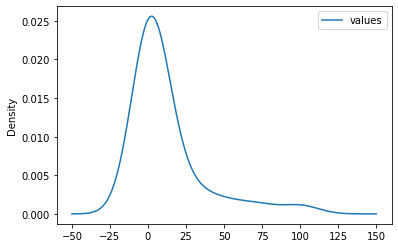

In [544]:
dfval.plot(kind='kde');

In [533]:
#swap two rows of a dataframe 2nd and 3rd

df = pd.DataFrame(np.arange(25).reshape(5, -1))
print(df)
a, b = df.iloc[2, :].copy(), df.iloc[3, :].copy()
df.iloc[2, :], df.iloc[3, :] = b, a

df.index=['a','b','c','d','e']
df

    0   1   2   3   4
0   0   1   2   3   4
1   5   6   7   8   9
2  10  11  12  13  14
3  15  16  17  18  19
4  20  21  22  23  24


,0,1,2,3,4
a,0,1,2,3,4
b,5,6,7,8,9
c,15,16,17,18,19
d,10,11,12,13,14
e,20,21,22,23,24


In [535]:
for i,row in df.iterrows():
    print(str(i) +"\n", row)

a
 0    0
1    1
2    2
3    3
4    4
Name: a, dtype: int64
b
 0    5
1    6
2    7
3    8
4    9
Name: b, dtype: int64
c
 0    15
1    16
2    17
3    18
4    19
Name: c, dtype: int64
d
 0    10
1    11
2    12
3    13
4    14
Name: d, dtype: int64
e
 0    20
1    21
2    22
3    23
4    24
Name: e, dtype: int64


In [542]:
df = pd.DataFrame(np.random.randint(1,100, 80).reshape(8, -1), columns=list('pqrstuvwxy'), index=list('abcdefgh'))
df

# Solution ???
abs_corrmat = np.abs(df.corr())
abs_corrmat
abs_corrmat.apply(lambda x: sorted(x))
#abs_corrmat
max_corr = abs_corrmat.apply(lambda x: sorted(x)[-2]) #not -1 bcoz the last row will be the one with the max corr from all column (ie 1 always)
print('Maximum Correlation possible for each column: ', np.round(max_corr.tolist(), 2))
abs_corrmat

Maximum Correlation possible for each column:  [0.48 0.69 0.65 0.66 0.65 0.69 0.57 0.48 0.66 0.47]


,p,q,r,s,t,u,v,w,x,y
p,1.000000,0.479807,0.017805,0.273608,0.250392,0.023572,0.464687,0.021434,0.085661,0.104125
q,0.479807,1.000000,0.187242,0.364976,0.538369,0.691304,0.200120,0.480679,0.374957,0.202189
r,0.017805,0.187242,1.000000,0.255685,0.645238,0.039170,0.450241,0.209367,0.498175,0.203295
s,0.273608,0.364976,0.255685,1.000000,0.150115,0.579844,0.208605,0.293117,0.658039,0.399786
t,0.250392,0.538369,0.645238,0.150115,1.000000,0.186813,0.410681,0.412943,0.110162,0.265522
u,0.023572,0.691304,0.039170,0.579844,0.186813,1.000000,0.158649,0.347354,0.531469,0.465326
v,0.464687,0.200120,0.450241,0.208605,0.410681,0.158649,1.000000,0.370882,0.571205,0.461833
w,0.021434,0.480679,0.209367,0.293117,0.412943,0.347354,0.370882,1.000000,0.049548,0.447537
x,0.085661,0.374957,0.498175,0.658039,0.110162,0.531469,0.571205,0.049548,1.000000,0.011666
y,0.104125,0.202189,0.203295,0.399786,0.265522,0.465326,0.461833,0.447537,0.011666,1.000000


In [409]:
#Compute the minimum-by-maximum for every row of df.

df = pd.DataFrame(np.random.randint(1,100, 80).reshape(8, -1))
df

,0,1,2,3,4,5,6,7,8,9
0,16,84,74,65,34,43,62,53,63,67
1,71,77,19,83,88,97,6,2,85,53
2,98,94,60,30,86,74,93,17,60,40
3,51,50,5,37,84,44,91,54,3,93
4,90,75,11,4,31,21,46,99,34,6
5,27,57,91,33,74,69,88,37,3,2
6,87,72,21,74,85,11,38,98,61,6
7,53,12,80,52,38,80,62,93,54,95


In [414]:
df = pd.DataFrame(np.random.randint(1,100, 80).reshape(8, -1)) #min of a row by max of a row
#min_by_max = df.apply(lambda x: np.min(x)/np.max(x), axis=1)
min_by_max1 = df.apply(lambda x: x.min()/x.max(), axis=1)
min_by_max1

0    0.032967
1    0.052083
2    0.091837
3    0.093750
4    0.306122
5    0.207317
6    0.102041
7    0.064103
dtype: float64

In [88]:
#Create a new column 'penultimate' which has the second largest value of each row of df ???

df = pd.DataFrame(np.random.randint(1,100, 80).reshape(16, -1))

df['penultimate']=df.apply(lambda x: x.sort_values().unique()[-2], axis=1)
df
df['pen']=df.apply(lambda x: x.sort_values(ascending=False).unique()[1], axis=1)
df

,0,1,2,3,4,penultimate,pen
0,67,98,36,47,51,67,67
1,60,55,9,32,65,60,60
2,59,19,48,2,52,52,52
3,19,64,70,11,92,70,70
4,18,96,97,14,18,96,96
5,14,33,59,60,76,60,60
6,85,77,39,16,51,77,77
7,30,47,16,47,9,30,30
8,69,35,10,91,35,69,69
9,64,55,23,80,60,64,64


In [429]:
df = pd.DataFrame(np.random.randint(1,100, 80).reshape(8, -1)) #normalization

out1 = df.apply(lambda x: ((x - x.mean())/x.std()).round(2), axis=1)
print('Solution Q1\n',out1)


out2 = df.apply(lambda x: ((x.max() - x)/(x.max() - x.min())).round(2), axis=1)
print('Solution Q2\n', out2)  

Solution Q1
       0     1     2     3     4     5     6     7     8     9
0 -0.02 -1.25 -0.30  1.13 -0.44 -1.77  1.23 -0.13  0.88  0.67
1  0.46 -0.97  0.85  1.07  1.02 -0.25  1.07 -1.33 -0.72 -1.19
2  0.92 -1.14  0.89 -0.41 -1.51  1.23  0.52  0.35 -1.25  0.41
3 -0.32  1.45  0.24 -1.58 -0.32  0.89  0.19  1.15 -0.32 -1.38
4 -1.58  0.63  0.63  0.87 -0.41 -1.17 -1.06  0.80  1.28  0.01
5 -0.52 -1.38  0.16  1.35 -1.19  0.99 -0.74 -0.52  1.06  0.80
6  1.02  1.21 -0.45 -0.91 -0.51  1.21 -1.46 -0.09 -0.91  0.89
7  0.55 -0.94 -1.60 -1.05 -0.70  1.01  1.01 -0.08  0.86  0.94
Solution Q2
       0     1     2     3     4     5     6     7     8     9
0  0.42  0.83  0.51  0.03  0.56  1.00  0.00  0.45  0.12  0.19
1  0.25  0.85  0.09  0.00  0.02  0.55  0.00  1.00  0.75  0.94
2  0.11  0.87  0.12  0.60  1.00  0.00  0.26  0.32  0.91  0.30
3  0.58  0.00  0.40  1.00  0.58  0.18  0.42  0.10  0.58  0.93
4  1.00  0.23  0.23  0.14  0.59  0.86  0.82  0.17  0.00  0.45
5  0.68  1.00  0.44  0.00  0.93  0.13  0.76 

In [89]:
#corr with the succeeding row

df = pd.DataFrame(np.random.randint(1,100, 80).reshape(8, -1))
print([df.iloc[i].corr(df.iloc[i+1]).round(2) for i in range(df.shape[0])[:-1]])
print([df.iloc[i].corr(df.iloc[i+1]).round(2) for i in range(df.shape[0])[:-1]])
[df.iloc[i].corr(df.iloc[i+1]).round(2) for i, row in df.iterrows() if i < len(df)-1]# in range(df.shape[0])[:-1]]

[-0.15, -0.13, -0.28, -0.04, 0.11, 0.26, 0.11]
[-0.15, -0.13, -0.28, -0.04, 0.11, 0.26, 0.11]


[-0.15, -0.13, -0.28, -0.04, 0.11, 0.26, 0.11]

In [33]:
df = pd.DataFrame(np.random.randint(1,100, 100).reshape(10, -1)) #make both the diagonal elements all 0s
print(df)
# Solution

for i in range(df.shape[0]):
    df.iat[i, i] = 0
   # df.iat[i,j]=0
 #   j-=1
df

    0   1   2   3   4   5   6   7   8   9
0  99  46  32  92  40  87  16  19  66  91
1  63  86  22  20  51  41  75  85  39  30
2  65  49  34  98  20  77  33   6  71  60
3  42  59  95   2  19  35  90  24  61  32
4  19  31  28  77  96  27  32  80  86  37
5  89  89  17  90  32  62  15  33  57  28
6  67  53  10  27  62  21  93  15  22  58
7  38  95  39  42  97  28  21  51  73  63
8  24  30  39  31  49  19  13   3  46  41
9  51  86  23   4  56  33  64  59  26   2


,0,1,2,3,4,5,6,7,8,9
0,0,46,32,92,40,87,16,19,66,91
1,63,0,22,20,51,41,75,85,39,30
2,65,49,0,98,20,77,33,6,71,60
3,42,59,95,0,19,35,90,24,61,32
4,19,31,28,77,0,27,32,80,86,37
5,89,89,17,90,32,0,15,33,57,28
6,67,53,10,27,62,21,0,15,22,58
7,38,95,39,42,97,28,21,0,73,63
8,24,30,39,31,49,19,13,3,0,41
9,51,86,23,4,56,33,64,59,26,0


In [34]:
#In df, find the second largest value of 'taste' for 'banana'
df = pd.DataFrame({'fruit': ['apple', 'banana', 'orange'] * 3,
                   'taste': np.random.rand(9),
                   'price': np.random.randint(0, 15, 9)})

print(df)



    fruit     taste  price
0   apple  0.813306      9
1  banana  0.612829     11
2  orange  0.781345      1
3   apple  0.570005      8
4  banana  0.415509      4
5  orange  0.886394      7
6   apple  0.325871     14
7  banana  0.130156      5
8  orange  0.431566      2


In [557]:
# Solution
df_grpd = df['taste'].groupby(df.fruit)
df_grpd.get_group('banana').sort_values().iloc[-2]


0.2990828148427246

In [50]:
df.groupby('fruit')['taste'].apply(list)['banana']

[0.6128290211566637, 0.4155088542364501, 0.13015572268294617]

In [49]:
banana_taste= sorted(df.groupby('fruit')['taste'].apply(list)['banana'], reverse= True)[1] #, key=lambda x:x[1]
banana_taste

0.4155088542364501

In [ ]:
banana_taste

In [106]:
df.groupby('fruit')['taste'].get_group('banana').sort_values(ascending=False).values[1], df.groupby('fruit')['taste'].size()


(0.3455199817715514,
 fruit
 apple     3
 banana    3
 orange    3
 Name: taste, dtype: int64)

In [450]:
#In df, Compute the mean price of every fruit, while keeping the fruit as another column instead of an index.
df = pd.DataFrame({'fruit': ['apple', 'banana', 'orange'] * 3,
                   'rating': np.random.rand(9),
                   'price': np.random.randint(0, 15, 9)})

# Solution
out = df.groupby('fruit', as_index=False)['price'].mean()
#out.index=[1,2,3]
print(out)

    fruit     price
0   apple  5.333333
1  banana  5.666667
2  orange  8.000000


In [107]:
df1 = pd.DataFrame({'fruit': ['apple', 'banana', 'orange'] * 3,  #???
                    'weight': ['high', 'medium', 'low'] * 3,
                    'price': np.random.randint(0, 15, 9)})

df2 = pd.DataFrame({'pazham': ['apple', 'orange', 'pine'] * 2,
                    'kilo': ['high', 'low'] * 3,
                    'price': np.random.randint(0, 15, 6)})

pd.concat(df1, df2, keys=['fruit', 'weight'], right_on=['pazham', 'price'], suffixes=['_left', '_right'])

<ipython-input-107-6f230b90e8ef>:9: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  pd.concat(df1, df2, keys=['fruit', 'weight'], right_on=['pazham', 'price'], suffixes=['_left', '_right'])


TypeError: concat() got an unexpected keyword argument 'right_on'

In [136]:
df =pd.DataFrame({'fruit1': np.random.choice(['apple', 'orange', 'banana'],10), #indices where 2 cols match ???
                    'fruit2': np.random.choice(['apple', 'orange', 'banana'], 10)})

# Solution
print(df.fruit1)
print(df.fruit2)
np.where(df.fruit1 == df.fruit2)
[(i, (a,b)) for i, (a,b) in enumerate(zip(df.fruit1, df.fruit2)) if a==b]

0    orange
1    banana
2    banana
3     apple
4    banana
5     apple
6     apple
7     apple
8    orange
9     apple
Name: fruit1, dtype: object
0     apple
1     apple
2    orange
3    orange
4    banana
5    orange
6    banana
7     apple
8    banana
9    banana
Name: fruit2, dtype: object


[(4, ('banana', 'banana')), (7, ('apple', 'apple'))]

In [115]:
[i for i,x in enumerate (list(df['fruit1'])) for j,y in enumerate(list(df['fruit2'])) if (x==y) and (i==j)]

[0, 1, 5, 6, 9]

In [460]:
#Create two new columns in df, one of which is a lag1 (shift column a down by 1 row) of column ‘a’ and the other is a lead1 (shift column b up by 1 row).
df = pd.DataFrame(np.random.randint(1, 100, 20).reshape(-1, 4), columns = list('abcd'))

# Solution
df['a_lag1'] = df['a'].shift(1)
df['b_lead1'] = df['b'].shift(-1)
print(df)

    a   b   c   d  a_lag1  b_lead1
0   1  60  35  63     NaN     40.0
1  16  40  70  36     1.0     65.0
2  27  65  55  70    16.0      1.0
3  25   1  55  58    27.0     88.0
4  91  88  61   6    25.0      NaN


In [70]:
#Get the frequency of unique values in the entire dataframe df
df = pd.DataFrame(np.random.randint(1, 10, 20).reshape(-1, 4), columns = list('abcd'))
print(df)
# Solution
pd.value_counts(df.values.ravel())

   a  b  c  d
0  4  7  9  9
1  4  2  9  2
2  6  5  2  1
3  9  7  2  5
4  5  6  2  8


/var/folders/88/96zsn82j511dx0zh7lxq70qm0000gn/T/ipykernel_6216/1563625678.py:5: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df.values.ravel())


2    5
9    4
5    3
4    2
7    2
6    2
1    1
8    1
Name: count, dtype: int64

In [51]:
from collections import Counter
df, df.values.ravel(), Counter(list(df.values.ravel()))
df

,fruit,taste,price
0,apple,0.813306,9
1,banana,0.612829,11
2,orange,0.781345,1
3,apple,0.570005,8
4,banana,0.415509,4
5,orange,0.886394,7
6,apple,0.325871,14
7,banana,0.130156,5
8,orange,0.431566,2


In [138]:
#Split the string column in df to form a dataframe with 3 columns ???
df = pd.DataFrame(["STD, City    State",
"33, Kolkata    West Bengal",
"44, Chennai    Tamil Nadu",
"40, Hyderabad    Telengana",
"80, Bangalore    Karnataka"], columns=['row'])

df_out = df['row'].str.split(',|\t', expand=True)
print (df['row'])
# Make first row as header
new_header = df_out.iloc[0,:]
df_out = df_out[1:]
df_out.columns = new_header
df_out.index=[0,1,2,3]
print(df_out)

0            STD, City    State
1    33, Kolkata    West Bengal
2     44, Chennai    Tamil Nadu
3    40, Hyderabad    Telengana
4    80, Bangalore    Karnataka
Name: row, dtype: object
0 STD            City    State
0  33   Kolkata    West Bengal
1  44    Chennai    Tamil Nadu
2  40   Hyderabad    Telengana
3  80   Bangalore    Karnataka


In [142]:
#1) Create a new column 'grade_rank' which ranks students based on their grade. Sort df in descending order based of this new column.
df['grade_rank'] = df['grade'].rank(ascending=False).astype('int64')
df = df.sort_values(by='grade_rank', ascending=False)
df

,name,grade,age,university,grade_rank
2,Tara,67,32,UT,6
4,Chris,73,19,UT,5
5,John,82,36,CMU,4
1,Bob,85,17,USC,3
3,Victoria,92,26,USC,2
0,Alex,99,21,CMU,1


In [148]:
df_new3=df.sort_values(by='grade', ascending=False)
df_new3['grade_rank']=np.arange(1, len(df_new3)+1)
df_new4= df_new3.sort_values(by='grade_rank', ascending=False)
df_new4.loc[df_new4['grade_rank'] == 1, 'grade_rank'] = 'First'
df_new4

/var/folders/88/96zsn82j511dx0zh7lxq70qm0000gn/T/ipykernel_30423/3605704837.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'First' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_new4.loc[df_new4['grade_rank'] == 1, 'grade_rank'] = 'First'


,name,grade,age,university,grade_rank
2,Tara,67,32,UT,6
4,Chris,73,19,UT,5
5,John,82,36,CMU,4
1,Bob,85,17,USC,3
3,Victoria,92,26,USC,2
0,Alex,99,21,CMU,First


In [66]:
df = pd.DataFrame({'name': ['Alex', 'Bob', 'Tara', 'Victoria', 'Chris', 'John'],'grade': [99, 85, 67, 92, 73, 82],'age': [21, 17, 32, 26, 19, 36],'university': ['CMU', 'USC', 'UT', 'USC', 'UT', 'CMU']})
df_copy=df.copy()

gradeRank=pd.Series(df['grade'].sort_values(ascending=False))
df['gradeRank']=gradeRank
df_s=df.sort_values(by='gradeRank', ascending=False)
df_s['rank']=df_s.index
gradeRank, df, df['gradeRank'], df_s, df_s.index

(0    99
 3    92
 1    85
 5    82
 4    73
 2    67
 Name: grade, dtype: int64,
        name  grade  age university  gradeRank
 0      Alex     99   21        CMU         99
 1       Bob     85   17        USC         85
 2      Tara     67   32         UT         67
 3  Victoria     92   26        USC         92
 4     Chris     73   19         UT         73
 5      John     82   36        CMU         82,
 0    99
 1    85
 2    67
 3    92
 4    73
 5    82
 Name: gradeRank, dtype: int64,
        name  grade  age university  gradeRank  rank
 0      Alex     99   21        CMU         99     0
 3  Victoria     92   26        USC         92     3
 1       Bob     85   17        USC         85     1
 5      John     82   36        CMU         82     5
 4     Chris     73   19         UT         73     4
 2      Tara     67   32         UT         67     2,
 Index([0, 3, 1, 5, 4, 2], dtype='int64'))

In [92]:
grade_s=df['grade'].sort_values(ascending=False)
grade_r=[i+1 for i,x in enumerate(grade_s)]
df_new_s=df.sort_values(by='grade', ascending=False)
df_new_s['grade_r']=grade_r
df_new_s.loc[0,"grade_r"]="FirstRank"
df_new_s

,name,grade,age,university,grade_r
0,Alex,99,21,CMU,FirstRank
3,Victoria,92,26,USC,2
1,Bob,85,17,USC,3
5,John,82,36,CMU,4
4,Chris,73,19,UT,5
2,Tara,67,32,UT,6


In [93]:
df_new.loc[df_new['grade_rank1']==6,'grade_rank1']="Last rank"
df_new

,name,grade,age,university,grade_rank1,grad
0,Alex,99,21,CMU,1,1
1,Bob,85,17,USC,3,2
2,Tara,67,32,UT,Last rank,3
3,Victoria,92,26,USC,2,4
4,Chris,73,19,UT,5,5
5,John,82,36,CMU,4,6


In [95]:
#df_new['grade_rank1'].replace("Last", 6, inplace=True) ???
#df_new.drop("grade_rank1", inplace=True, axis=1)
df_new.assign(grade_age=df_new['grade']+10)
df_new['grade_age1']=df['grade'].apply(lambda x:x+10)
df_new

,name,grade,age,university,grade_rank1,grad,grade_age,grade_age1
0,Alex,99,21,CMU,1,1,99,109
1,Bob,85,17,USC,3,2,85,95
2,Tara,67,32,UT,Last rank,3,67,77
3,Victoria,92,26,USC,2,4,92,102
4,Chris,73,19,UT,5,5,73,83
5,John,82,36,CMU,4,6,82,92


In [71]:
class Circle:
    
    

    def __init__(self,r):
        self.r=r
        
    def radius(self):
        print("The Radius of the cirsle is {}".format(self.r))
        
        
c=Circle(50)
c.radius()


The Radius of the cirsle is 50


__init__() is not a constructor. __init__() is a method that gets called after the instance is constructed. It lets you add some code that you want to execute before any other method other than __new__(). I think __new__() is a better fit for "constructor". After __new__() an instance knows how to act like an instance of the class, it just doesn't have any instance variables. I think a better description of __init__() is "initializer".

The python __init__ method is declared within a class and is used to initialize the attributes of an object as soon as the object is formed. While giving the definition for an __init__(self) method, a default parameter, named 'self' is always passed in its argument. This self represents the object of the class itself.